# **1. Introduction to the real-world problem**


# Dataset description

# Data cleaning


Se realizó una inspección inicial del dataset para identificar valores faltantes, inconsistencias y posibles duplicados. A partir del análisis, se observó que el conjunto de datos no contiene valores nulos, lo que indica que no es necesario aplicar técnicas de imputación.

Se encontraron registros duplicados, por lo que fue necesario eliminar observaciones. Esto garantiza que el dataset es consistente y adecuado para el entrenamiento del modelo.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

In [2]:
# Convertir a DataFrame de Pandas
df = pd.read_excel('/content/Dry_Bean_Dataset.xlsx')


encoder = LabelEncoder()
df["Class"] = encoder.fit_transform(df["Class"])


# Validación de datos y manejo de valores faltantes
# Conteo por columna y suma de todas las columnas.
if df.isnull().sum().sum():
    print("Existen valores faltantes en el dataset.")
else:
    print("No existen valores faltantes en el dataset.")

if df.duplicated().sum().sum():
    print("Existen valores duplicados en el dataset.")
else:
    print("No existen valores duplicados en el dataset.")

No existen valores faltantes en el dataset.
Existen valores duplicados en el dataset.


In [3]:
duplicates = df.duplicated().sum()
print("Duplicados:", duplicates)

Duplicados: 68


No hay muchos valores duplicados, podemos eliminarlos.

In [4]:
df = df.drop_duplicates()

In [5]:
df

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,5
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,5
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,5
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,5
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13606,42097,759.696,288.721612,185.944705,1.552728,0.765002,42508,231.515799,0.714574,0.990331,0.916603,0.801865,0.006858,0.001749,0.642988,0.998385,3
13607,42101,757.499,281.576392,190.713136,1.476439,0.735702,42494,231.526798,0.799943,0.990752,0.922015,0.822252,0.006688,0.001886,0.676099,0.998219,3
13608,42139,759.321,281.539928,191.187979,1.472582,0.734065,42569,231.631261,0.729932,0.989899,0.918424,0.822730,0.006681,0.001888,0.676884,0.996767,3
13609,42147,763.779,283.382636,190.275731,1.489326,0.741055,42667,231.653248,0.705389,0.987813,0.907906,0.817457,0.006724,0.001852,0.668237,0.995222,3


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13543 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13543 non-null  int64  
 1   Perimeter        13543 non-null  float64
 2   MajorAxisLength  13543 non-null  float64
 3   MinorAxisLength  13543 non-null  float64
 4   AspectRation     13543 non-null  float64
 5   Eccentricity     13543 non-null  float64
 6   ConvexArea       13543 non-null  int64  
 7   EquivDiameter    13543 non-null  float64
 8   Extent           13543 non-null  float64
 9   Solidity         13543 non-null  float64
 10  roundness        13543 non-null  float64
 11  Compactness      13543 non-null  float64
 12  ShapeFactor1     13543 non-null  float64
 13  ShapeFactor2     13543 non-null  float64
 14  ShapeFactor3     13543 non-null  float64
 15  ShapeFactor4     13543 non-null  float64
 16  Class            13543 non-null  int64  
dtypes: float64(14), i

# Exploratory Data Analysis

In [7]:
df['Class'].value_counts()

,count
Class,
3,3546
6,2636
5,2027
4,1860
2,1630
0,1322
1,522


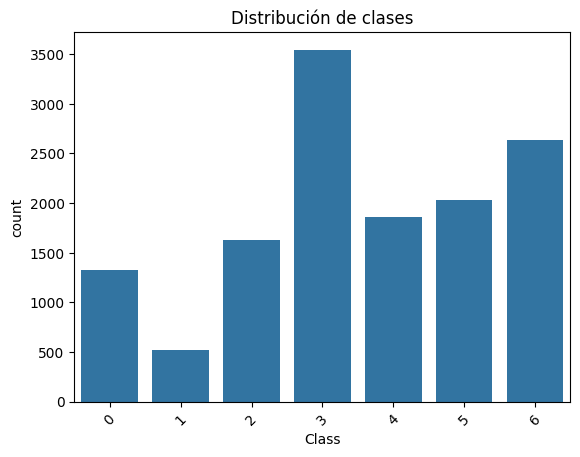

In [8]:
sns.countplot(x="Class", data=df)
plt.title("Distribución de clases")
plt.xticks(rotation=45)
plt.show()

La distribución de clases muestra que el dataset contiene 7 categorías correspondientes a diferentes tipos de frijol. Se observa que las clases no están perfectamente balanceadas, lo que podría influir en el desempeño del modelo, favoreciendo aquellas clases con mayor número de muestras.

In [9]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
count,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000,13543.000000
mean,53048.460385,854.993406,319.895602,202.365321,1.581075,0.750315,53767.986709,253.034094,0.749829,0.987152,0.873671,0.800352,0.006561,0.001719,0.644341,0.995078,3.530311
std,29392.438324,214.722684,85.809260,45.051632,0.245245,0.091858,29844.248525,59.307709,0.048939,0.004650,0.059393,0.061464,0.001130,0.000595,0.098653,0.004347,1.832994
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687,0.000000
25%,36282.500000,703.230000,253.086806,175.886357,1.430662,0.715144,36673.000000,214.933277,0.718735,0.985678,0.833410,0.763228,0.005893,0.001158,0.582517,0.993720,2.000000
50%,44580.000000,793.896000,296.404589,192.491117,1.549860,0.763997,45122.000000,238.245711,0.759903,0.988288,0.883490,0.801514,0.006643,0.001700,0.642424,0.996393,3.000000
75%,61382.000000,977.146500,376.312489,217.245403,1.703916,0.809671,62360.000000,279.560351,0.786849,0.990019,0.917031,0.834470,0.007270,0.002173,0.696341,0.997891,5.000000
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733,6.000000


Al analizar la escala y variabilidad de cada variable se observa que algunas características presentan valores en rangos significativamente distintos. Debido a esto ocupamos hacer una estandarización antes de entrenar el modelo.

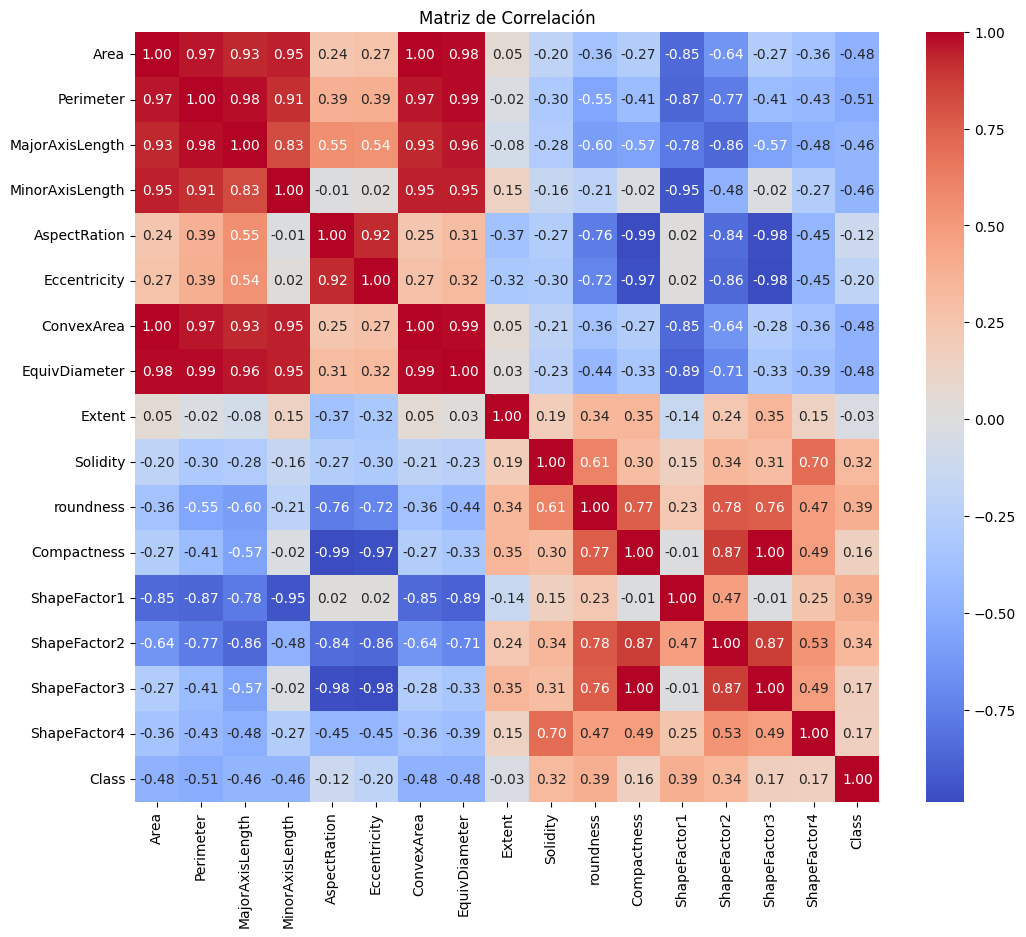

In [10]:
# Análisis de correlación entre las variables para identificar posibles relaciones
correlation_matrix = df.iloc[:, 0:17].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

# **2. Design and Training of the Multilayer Neural Network**

In [11]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.7 MB/s eta 0:00:00


In [12]:
# Importar librerías para la construcción del modelo de red neuronal
import plotly.express as px
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model
import optuna
from tensorflow import keras
from tensorflow.keras import layers

Para entrenar y optimizar el modelo los datos se van a separar en 70% de entrenamiento, 15% para la validacion de la optimización y 15% de prueba para el modelo.

In [13]:
tf.random.set_seed(4500)
X = df.drop(columns=['Class'])
y = df['Class']
X_train, X_t_v, y_train, y_t_v = train_test_split(X, y, test_size=0.3, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_t_v, y_t_v, test_size=0.5, random_state=42)

In [14]:
# Estandarización de las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [38]:
# Modelo base
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(64, activation='relu'),
    layers.Dense(16, activation='relu'),

    layers.Dense(7, activation='softmax')


])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_43"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_175 (Dense)               │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,247 (8.78 KB)

 Trainable params: 2,247 (8.78 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [39]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8113 - loss: 0.7081 - val_accuracy: 0.9035 - val_loss: 0.3062
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9184 - loss: 0.2457 - val_accuracy: 0.9035 - val_loss: 0.2530
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9223 - loss: 0.2154 - val_accuracy: 0.9055 - val_loss: 0.2421
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9242 - loss: 0.2054 - val_accuracy: 0.9090 - val_loss: 0.2365
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9257 - loss: 0.1999 - val_accuracy: 0.9119 - val_loss: 0.2331


# Optimización de Hiperparámetros

In [45]:
def objective(trial):

    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    num_layers = trial.suggest_int("num_layers", 2, 4)

    model = tf.keras.Sequential()

    # Capa de entrada
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    # Capas ocultas
    for i in range(num_layers):
        units = trial.suggest_int(f"units_l{i}", 16, 512)
        model.add(tf.keras.layers.Dense(units, activation='relu'))

    # Capa de salida
    model.add(tf.keras.layers.Dense(7, activation='softmax'))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=100,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Retornamos el mejor accuracy de validación
    return max(history.history['val_accuracy'])

In [46]:
# 3. Ejecución de la Optimización
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=30)

# 4. Guardar y evaluar el mejor modelo
print(f"Mejor configuración: {study.best_params}")

[I 2026-03-26 00:21:24,926] A new study created in memory with name: no-name-638aa2eb-1ba8-4400-83be-b8c0378c506c
[I 2026-03-26 00:21:47,615] Trial 0 finished with value: 0.9178149700164795 and parameters: {'learning_rate': 0.0016832379277249778, 'batch_size': 64, 'num_layers': 3, 'units_l0': 193, 'units_l1': 441, 'units_l2': 88}. Best is trial 0 with value: 0.9178149700164795.
[I 2026-03-26 00:22:08,486] Trial 1 finished with value: 0.9227362275123596 and parameters: {'learning_rate': 0.0008475428628378055, 'batch_size': 64, 'num_layers': 3, 'units_l0': 29, 'units_l1': 117, 'units_l2': 192}. Best is trial 0 with value: 0.9178149700164795.
[I 2026-03-26 00:22:58,445] Trial 2 finished with value: 0.9202755689620972 and parameters: {'learning_rate': 0.00012328991945284942, 'batch_size': 64, 'num_layers': 2, 'units_l0': 38, 'units_l1': 131}. Best is trial 0 with value: 0.9178149700164795.
[I 2026-03-26 00:23:50,886] Trial 3 finished with value: 0.9207677245140076 and parameters: {'learnin

Mejor configuración: {'learning_rate': 0.004869475568635482, 'batch_size': 64, 'num_layers': 2, 'units_l0': 371, 'units_l1': 226}


In [32]:
# Modelo Optimizado
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),

    layers.Dense(220, activation='relu'),
    layers.Dense(216, activation='relu'),
    layers.Dense(218, activation='relu'),

    layers.Dense(7, activation='softmax')


])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00021098988045467712),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_80 (Dense)                │ (None, 220)            │         3,740 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 216)            │        47,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_82 (Dense)                │ (None, 218)            │        47,306 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 7)              │         1,533 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 100,315 (391.86 KB)

 Trainable params: 100,315 (391.86 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8312 - loss: 0.5601 - val_accuracy: 0.9001 - val_loss: 0.2678
Epoch 2/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9172 - loss: 0.2285 - val_accuracy: 0.9094 - val_loss: 0.2388
Epoch 3/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9230 - loss: 0.2050 - val_accuracy: 0.9134 - val_loss: 0.2317
Epoch 4/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9255 - loss: 0.1967 - val_accuracy: 0.9139 - val_loss: 0.2289
Epoch 5/100
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9271 - loss: 0.1917 - val_accuracy: 0.9119 - val_loss: 0.2269
